# Iron Kaggle — Store Sales Prediction
**Goal:** Predict daily store sales using the training dataset.  
**Target:** `sales` (regression)  
**Metric:** R² Score

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
print('Libraries imported successfully!')


Libraries imported successfully!


---
## 2. Load and Inspect the Dataset

In [2]:
df = pd.read_csv('training.csv')
print('Shape:', df.shape)
df.head()

Shape: (640840, 10)


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


In [4]:
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [5]:
# Check unique values for categorical columns
print('state_holiday unique values:', df['state_holiday'].unique())
print('open value counts:\n', df['open'].value_counts())
print('school_holiday value counts:\n', df['school_holiday'].value_counts())
print('promotion value counts:\n', df['promotion'].value_counts())

state_holiday unique values: ['0' 'a' 'c' 'b']
open value counts:
 open
1    532016
0    108824
Name: count, dtype: int64
school_holiday value counts:
 school_holiday
0    526468
1    114372
Name: count, dtype: int64
promotion value counts:
 promotion
0    396220
1    244620
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

In [6]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


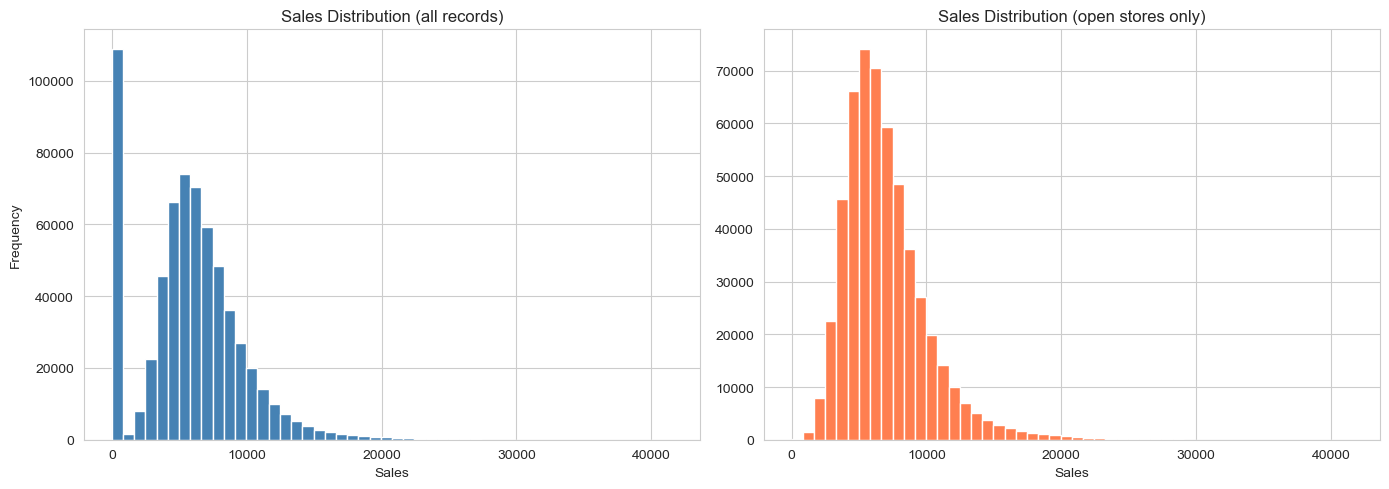

Records where store is closed (sales=0): 108824 (17.0%)


In [7]:
# Sales distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution (all records)')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Sales when store is open only (more meaningful)
open_sales = df[df['open'] == 1]['sales']
axes[1].hist(open_sales, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Sales Distribution (open stores only)')
axes[1].set_xlabel('Sales')

plt.tight_layout()
plt.show()

print(f'Records where store is closed (sales=0): {(df["open"]==0).sum()} ({(df["open"]==0).mean()*100:.1f}%)')

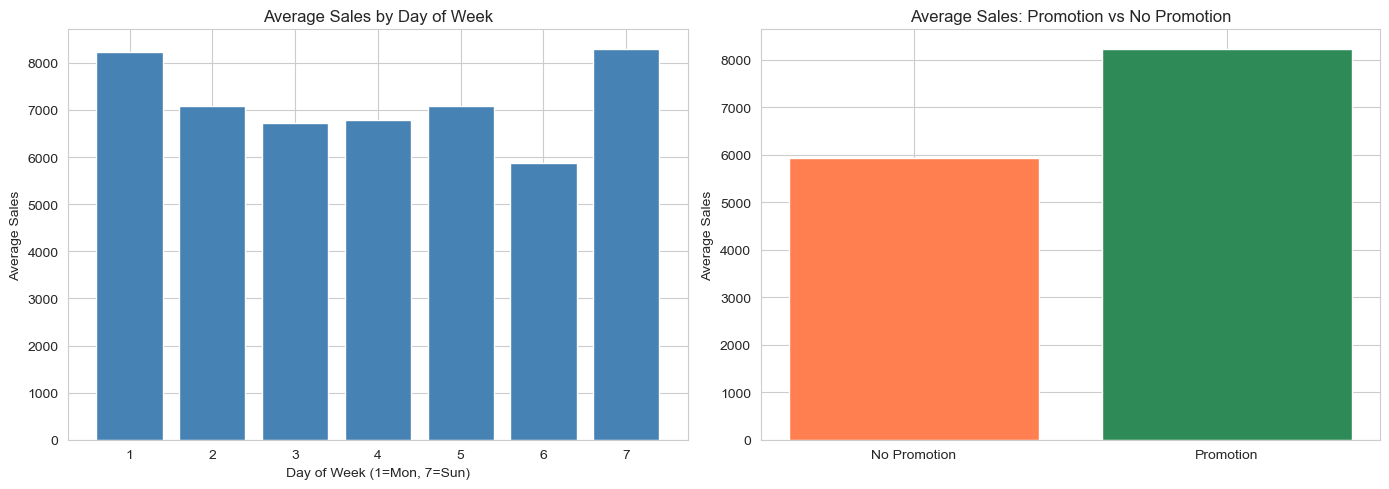

In [8]:
# Average sales by day of week
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_sales = df[df['open']==1].groupby('day_of_week')['sales'].mean()
axes[0].bar(day_sales.index, day_sales.values, color='steelblue')
axes[0].set_title('Average Sales by Day of Week')
axes[0].set_xlabel('Day of Week (1=Mon, 7=Sun)')
axes[0].set_ylabel('Average Sales')

# Sales with/without promotion
promo_sales = df[df['open']==1].groupby('promotion')['sales'].mean()
axes[1].bar(['No Promotion', 'Promotion'], promo_sales.values, color=['coral', 'seagreen'])
axes[1].set_title('Average Sales: Promotion vs No Promotion')
axes[1].set_ylabel('Average Sales')

plt.tight_layout()
plt.show()

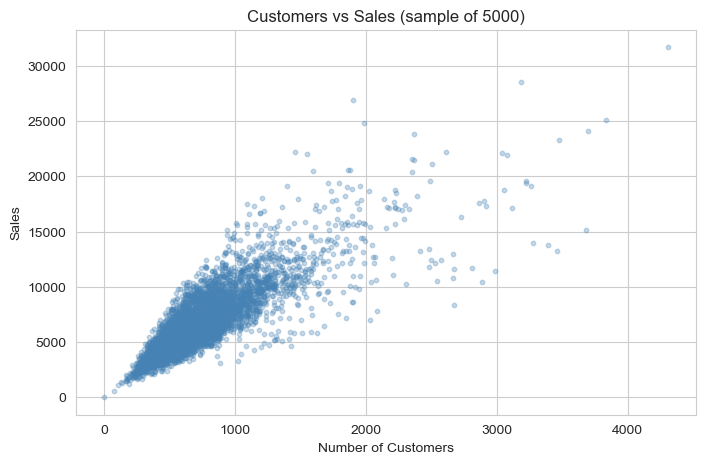

Correlation between nb_customers_on_day and sales: 0.8237


In [9]:
# Correlation between nb_customers and sales
open_df = df[df['open'] == 1]
plt.figure(figsize=(8, 5))
plt.scatter(open_df['nb_customers_on_day'].sample(5000, random_state=42),
            open_df['sales'].sample(5000, random_state=42),
            alpha=0.3, color='steelblue', s=10)
plt.title('Customers vs Sales (sample of 5000)')
plt.xlabel('Number of Customers')
plt.ylabel('Sales')
plt.show()

corr = open_df[['nb_customers_on_day', 'sales']].corr()
print('Correlation between nb_customers_on_day and sales:', corr.loc['nb_customers_on_day', 'sales'].round(4))

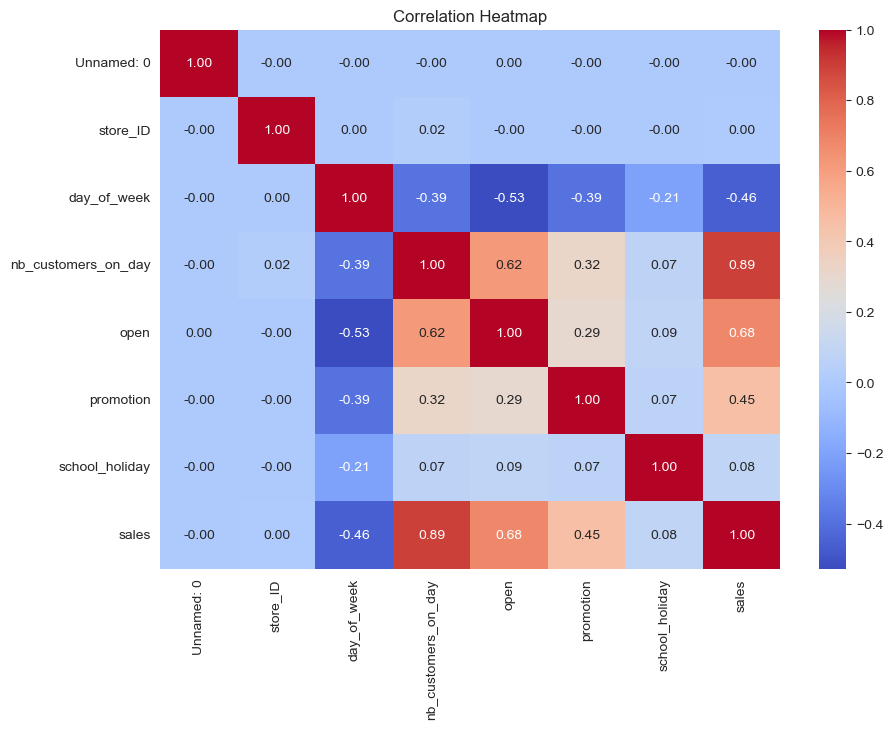

In [10]:
# Correlation heatmap (numeric columns)
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Observations:**
- ~17% of records are for closed stores (sales = 0). These are trivial and should be filtered out.
- `nb_customers_on_day` has a very strong positive correlation with `sales`.
- Promotions noticeably increase average sales.
- Monday and Sunday show different sales patterns.

---
## 4. Data Cleaning

In [11]:
# Filter: keep only open store days (closed stores have sales=0, not useful for prediction)
df_clean = df[df['open'] == 1].copy()
print(f'Rows before filtering: {len(df)}')
print(f'Rows after filtering (open only): {len(df_clean)}')

# Drop the index column and 'open' (all 1s now)
df_clean.drop(columns=['Unnamed: 0', 'open'], inplace=True)
print('Dropped: Unnamed: 0, open')
df_clean.head()

Rows before filtering: 640840
Rows after filtering (open only): 532016
Dropped: Unnamed: 0, open


,store_ID,day_of_week,date,nb_customers_on_day,promotion,state_holiday,school_holiday,sales
0,366,4,2013-04-18,517,0,0,0,4422
1,394,6,2015-04-11,694,0,0,0,8297
2,807,4,2013-08-29,970,1,0,0,9729
3,802,2,2013-05-28,473,1,0,0,6513
4,726,4,2013-10-10,1068,1,0,0,10882


In [12]:
# Confirm no missing values remain
print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


---
## 5. Feature Engineering

In [13]:
# Parse date column and extract time features
df_clean['date'] = pd.to_datetime(df_clean['date'])

df_clean['month']        = df_clean['date'].dt.month
df_clean['year']         = df_clean['date'].dt.year
df_clean['week']         = df_clean['date'].dt.isocalendar().week.astype(int)
df_clean['day_of_month'] = df_clean['date'].dt.day
df_clean['is_weekend']   = (df_clean['day_of_week'] >= 6).astype(int)

print('New date features added: month, year, week, day_of_month, is_weekend')
df_clean[['date','month','year','week','day_of_month','is_weekend']].head()

New date features added: month, year, week, day_of_month, is_weekend


,date,month,year,week,day_of_month,is_weekend
0,2013-04-18,4,2013,16,18,0
1,2015-04-11,4,2015,15,11,1
2,2013-08-29,8,2013,35,29,0
3,2013-05-28,5,2013,22,28,0
4,2013-10-10,10,2013,41,10,0


In [14]:
# Store-level aggregation features (mean, median, std of sales per store)
# These capture the baseline performance of each store
store_stats = df_clean.groupby('store_ID')['sales'].agg(['mean','median','std'])
store_stats.columns = ['store_mean_sales', 'store_med_sales', 'store_std_sales']
store_stats = store_stats.reset_index()

df_clean = df_clean.merge(store_stats, on='store_ID', how='left')
print('Store-level features added: store_mean_sales, store_med_sales, store_std_sales')
df_clean[['store_ID','store_mean_sales','store_med_sales','store_std_sales']].head()

Store-level features added: store_mean_sales, store_med_sales, store_std_sales


,store_ID,store_mean_sales,store_med_sales,store_std_sales
0,366,6206.869739,6011.0,2217.926336
1,394,8404.937378,8207.0,1997.824459
2,807,9824.892713,9773.5,1678.089636
3,802,6754.329060,6561.0,1652.507819
4,726,11052.675620,10497.5,3809.830786


---
## 6. Encoding Categorical Variables

In [15]:
# We will use one-hot encoding later for categorical columns
# so we keep state_holiday in its original form here.
print('Using one-hot encoding for state_holiday and store_ID later.')


Using one-hot encoding for state_holiday and store_ID later.


---
## 7. Prepare Features and Target

In [16]:
FEATURES = [
    'store_ID',
    'day_of_week',
    'nb_customers_on_day',
    'promotion',
    'state_holiday',
    'school_holiday',
    'month',
    'year',
    'week',
    'day_of_month',
    'is_weekend',
    'store_mean_sales',
    'store_med_sales',
    'store_std_sales',
]

TARGET = 'sales'

X = df_clean[FEATURES]
y = df_clean[TARGET]

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape:         {y.shape}')
print(f'Features used: {FEATURES}')


Feature matrix shape: (532016, 14)
Target shape:         (532016,)
Features used: ['store_ID', 'day_of_week', 'nb_customers_on_day', 'promotion', 'state_holiday', 'school_holiday', 'month', 'year', 'week', 'day_of_month', 'is_weekend', 'store_mean_sales', 'store_med_sales', 'store_std_sales']


---
## 8. Train / Validation / Test Split

We use a **time-based 3-way split** — Train (70%) → Validation (15%) → Test (15%).  
- **Train**: model learns from this  
- **Validation**: used during development to tune and compare models  
- **Test**: held out until the very end — gives an honest final accuracy estimate

In [17]:
# Sort by date for a realistic temporal split
df_sorted = df_clean.sort_values('date')
X_sorted  = X.loc[df_sorted.index]
y_sorted  = y.loc[df_sorted.index]

train_end = int(len(df_sorted) * 0.70)
val_end   = int(len(df_sorted) * 0.85)

X_train = X_sorted.iloc[:train_end].copy()
X_val   = X_sorted.iloc[train_end:val_end].copy()
X_test  = X_sorted.iloc[val_end:].copy()

y_train = y_sorted.iloc[:train_end]
y_val   = y_sorted.iloc[train_end:val_end]
y_test  = y_sorted.iloc[val_end:]

# One-hot encode categorical columns
X_train = pd.get_dummies(X_train, columns=['store_ID', 'state_holiday'], drop_first=False)
X_val   = pd.get_dummies(X_val,   columns=['store_ID', 'state_holiday'], drop_first=False)
X_test  = pd.get_dummies(X_test,  columns=['store_ID', 'state_holiday'], drop_first=False)

# Align validation/test columns to training columns
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Reduce memory
X_train = X_train.astype('float32')
X_val   = X_val.astype('float32')
X_test  = X_test.astype('float32')

print(f'Training set   : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validation set : {len(X_val):,} rows  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test set       : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.0f}%)')
print()
print(f'Train dates : {df_sorted["date"].iloc[0].date()} → {df_sorted["date"].iloc[train_end-1].date()}')
print(f'Val dates   : {df_sorted["date"].iloc[train_end].date()} → {df_sorted["date"].iloc[val_end-1].date()}')
print(f'Test dates  : {df_sorted["date"].iloc[val_end].date()} → {df_sorted["date"].iloc[-1].date()}')
print()
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape  : {X_val.shape}')
print(f'X_test shape : {X_test.shape}')


Training set   : 372,411 rows  (70%)
Validation set : 79,802 rows  (15%)
Test set       : 79,803 rows  (15%)

Train dates : 2013-01-01 → 2014-10-18
Val dates   : 2014-10-18 → 2015-03-16
Test dates  : 2015-03-16 → 2015-07-31

X_train shape: (372411, 1131)
X_val shape  : (79802, 1131)
X_test shape : (79803, 1131)


---
## 9. Baseline Model — Linear Regression

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train_r2 = r2_score(y_train, lr.predict(X_train))
lr_val_r2   = r2_score(y_val,   lr.predict(X_val))
lr_test_r2  = r2_score(y_test,  lr.predict(X_test))

print('Linear Regression')
print(f'  Train R²      : {lr_train_r2:.4f}  ({lr_train_r2*100:.2f}%)')
print(f'  Validation R² : {lr_val_r2:.4f}  ({lr_val_r2*100:.2f}%)')
print(f'  Test R²       : {lr_test_r2:.4f}  ({lr_test_r2*100:.2f}%)')


Linear Regression
  Train R²      : 0.7398  (73.98%)
  Validation R² : 0.7264  (72.64%)
  Test R²       : 0.7052  (70.52%)


---
## 10. Model 2 — Random Forest Regressor

In [19]:
# Use a sample for faster training during exploration
sample_frac = 0.20  # increase to 1.0 for final training
X_tr_s = X_train.sample(frac=sample_frac, random_state=42)
y_tr_s = y_train.loc[X_tr_s.index]

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr_s, y_tr_s)

rf_train_r2 = r2_score(y_tr_s, rf.predict(X_tr_s))
rf_val_r2   = r2_score(y_val,  rf.predict(X_val))
rf_test_r2  = r2_score(y_test, rf.predict(X_test))

print('Random Forest Regressor')
print(f'  Train R²      : {rf_train_r2:.4f}  ({rf_train_r2*100:.2f}%)')
print(f'  Validation R² : {rf_val_r2:.4f}  ({rf_val_r2*100:.2f}%)')
print(f'  Test R²       : {rf_test_r2:.4f}  ({rf_test_r2*100:.2f}%)')

Random Forest Regressor
  Train R²      : 0.9670  (96.70%)
  Validation R² : 0.9245  (92.45%)
  Test R²       : 0.9082  (90.82%)


---
## 11. Model 3 — Gradient Boosting Regressor (Best Model)

In [20]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb.fit(X_tr_s, y_tr_s)  # same sample as RF for fair comparison

gb_train_r2 = r2_score(y_tr_s, gb.predict(X_tr_s))
gb_val_r2   = r2_score(y_val,  gb.predict(X_val))
gb_test_r2  = r2_score(y_test, gb.predict(X_test))

print('Gradient Boosting Regressor')
print(f'  Train R²      : {gb_train_r2:.4f}  ({gb_train_r2*100:.2f}%)')
print(f'  Validation R² : {gb_val_r2:.4f}  ({gb_val_r2*100:.2f}%)')
print(f'  Test R²       : {gb_test_r2:.4f}  ({gb_test_r2*100:.2f}%)')

Gradient Boosting Regressor
  Train R²      : 0.9347  (93.47%)
  Validation R² : 0.9196  (91.96%)
  Test R²       : 0.8973  (89.73%)


In [ ]:
# Model 4 - XGBoost

## XGBoost Modeling

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── 1. Log-Transform Target ───────────────────────────────────
y = np.log1p(y)
print('Applied log1p transform to sales')

# ── 2. Train / Validation Split ───────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print(f'Train size: {len(X_train)}, Validation size: {len(X_val)}')

# ── 3. Metrics Function ───────────────────────────────────────
def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f'── {label} Performance ──')
    print(f'  MAE  : {mae:.2f}       (avg error in sales units)')
    print(f'  RMSE : {rmse:.2f}      (penalises large errors more)')
    print(f'  MAPE : {mape:.2f}%     (avg % error)')
    print(f'  R²   : {r2:.4f}        (1.0 = perfect)')
    print()

# Reverse log transform for reuse
y_train_actual = np.expm1(y_train)
y_val_actual   = np.expm1(y_val)

# ── 4. Define Parameter Sets ──────────────────────────────────
param_sets = {
    'Reduce Overfitting': {
        'n_estimators'    : 200,
        'learning_rate'   : 0.1,
        'max_depth'       : 4,
        'subsample'       : 0.7,
        'colsample_bytree': 0.7,
        'min_child_weight': 10,
        'gamma'           : 0.1,
        'random_state'    : 42,
        'n_jobs'          : -1
    },
    'Add Regularisation': {
        'n_estimators'    : 350,
        'learning_rate'   : 0.05,
        'max_depth'       : 6,
        'subsample'       : 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 5,
        'reg_alpha'       : 0.1,
        'reg_lambda'      : 1.5,
        'random_state'    : 42,
        'n_jobs'          : -1
    },
    'Improve Accuracy': {
        'n_estimators'    : 500,
        'learning_rate'   : 0.02,
        'max_depth'       : 6,
        'subsample'       : 0.9,
        'colsample_bytree': 0.9,
        'min_child_weight': 3,
        'reg_alpha'       : 0.05,
        'reg_lambda'      : 1.0,
        'random_state'    : 42,
        'n_jobs'          : -1
    }
}

# ── 5. Loop Through Parameter Sets ────────────────────────────
results  = {}
models   = {}

for name, params in param_sets.items():
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'{"="*50}')

    # Train
    model = XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=100
    )
    models[name] = model

    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)

    # Reverse log transform
    y_pred_train_actual = np.expm1(y_pred_train)
    y_pred_val_actual   = np.expm1(y_pred_val)

    # Evaluate
    evaluate(y_train_actual, y_pred_train_actual, f'{name} — Training')
    evaluate(y_val_actual,   y_pred_val_actual,   f'{name} — Validation')

    # Actual vs Predicted Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, y_true, y_pred, label in zip(
        axes,
        [y_train_actual, y_val_actual],
        [y_pred_train_actual, y_pred_val_actual],
        ['Training', 'Validation']
    ):
        ax.scatter(y_true, y_pred, alpha=0.3, s=5, color='steelblue')
        ax.plot([0, y_true.max()], [0, y_true.max()], 'r--', label='Perfect Prediction')
        ax.set_xlabel('Actual Sales')
        ax.set_ylabel('Predicted Sales')
        ax.set_title(f'{name} — Actual vs Predicted ({label})')
        ax.legend()
    plt.tight_layout()
    plt.show()

    # Residuals Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, y_true, y_pred, label in zip(
        axes,
        [y_train_actual, y_val_actual],
        [y_pred_train_actual, y_pred_val_actual],
        ['Training', 'Validation']
    ):
        residuals = y_true - y_pred
        ax.scatter(y_pred, residuals, alpha=0.3, s=5, color='steelblue')
        ax.axhline(0, color='red', linestyle='--')
        ax.set_xlabel('Predicted Sales')
        ax.set_ylabel('Residuals (Actual - Predicted)')
        ax.set_title(f'{name} — Residuals Plot ({label})')
    plt.tight_layout()
    plt.show()

    # Feature Importance
    importance        = pd.Series(model.feature_importances_, index=FEATURES)
    importance_sorted = importance.sort_values(ascending=False)
    print(f'\n── Feature Importances ({name}) ──')
    print(importance_sorted)
    plt.figure(figsize=(10, 6))
    importance_sorted.plot(kind='bar', color='steelblue')
    plt.title(f'XGBoost — Feature Importances ({name})')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Early Stopping Summary
    try:
        print(f'Best iteration: {model.best_iteration}')
    except AttributeError:
        print(f'No early stopping — n_estimators: {params["n_estimators"]}')

    # Store results
    results[name] = {
        'val_mae'  : mean_absolute_error(y_val_actual, y_pred_val_actual),
        'val_rmse' : np.sqrt(mean_squared_error(y_val_actual, y_pred_val_actual)),
        'val_mape' : np.mean(np.abs((y_val_actual - y_pred_val_actual) / y_val_actual)) * 100,
        'val_r2'   : r2_score(y_val_actual, y_pred_val_actual)
    }

# ── 6. Summary Comparison Table ───────────────────────────────
print(f'\n{"="*50}')
print('── Summary: Validation Performance Across All Parameter Sets ──')
print(f'{"="*50}')
summary_df = pd.DataFrame(results).T
summary_df.columns = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
print(summary_df.round(4))

# ── 7. Summary Comparison Plots ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_df['R²'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Validation R² Comparison')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

summary_df['MAE'].plot(kind='bar', ax=axes[1], color='orange', edgecolor='white')
axes[1].set_title('Validation MAE Comparison')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ── 8. Select Best Model ──────────────────────────────────────
best_name  = summary_df['R²'].idxmax()
best_model = models[best_name]
print(f'\nBest parameter set: {best_name}')
print(f'Best Validation R²: {summary_df.loc[best_name, "R²"]:.4f}')


In [ ]:
# Model 5 - Decision Tree
from sklearn.tree import DecisionTreeRegressor

# ── 1. Define Parameter Sets ──────────────────────────────────
param_sets_dt = {
    'Shallow Tree (Underfit)': {
        'max_depth'        : 3,
        'min_samples_split': 50,
        'min_samples_leaf' : 20,
        'random_state'     : 42
    },
    'Balanced Tree': {
        'max_depth'        : 6,
        'min_samples_split': 20,
        'min_samples_leaf' : 10,
        'random_state'     : 42
    },
    'Deep Tree (Overfit)': {
        'max_depth'        : None,
        'min_samples_split': 2,
        'min_samples_leaf' : 1,
        'random_state'     : 42
    }
}

# ── 2. Loop Through Parameter Sets ────────────────────────────
results_dt = {}
dt_models  = {}

for name, params in param_sets_dt.items():
    print(f'\n{"="*50}')
    print(f'Training Decision Tree: {name}')
    print(f'{"="*50}')

    # Train
    dt_model = DecisionTreeRegressor(**params)
    dt_model.fit(X_train, y_train)
    dt_models[name] = dt_model

    # Predict
    y_pred_train_dt = dt_model.predict(X_train)
    y_pred_val_dt   = dt_model.predict(X_val)

    # Reverse log transform
    y_pred_train_dt_actual = np.expm1(y_pred_train_dt)
    y_pred_val_dt_actual   = np.expm1(y_pred_val_dt)

    # Evaluate
    evaluate(y_train_actual, y_pred_train_dt_actual, f'{name} — Training')
    evaluate(y_val_actual,   y_pred_val_dt_actual,   f'{name} — Validation')

    # Actual vs Predicted Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, y_true, y_pred, label in zip(
        axes,
        [y_train_actual, y_val_actual],
        [y_pred_train_dt_actual, y_pred_val_dt_actual],
        ['Training', 'Validation']
    ):
        ax.scatter(y_true, y_pred, alpha=0.3, s=5, color='steelblue')
        ax.plot([0, y_true.max()], [0, y_true.max()], 'r--', label='Perfect Prediction')
        ax.set_xlabel('Actual Sales')
        ax.set_ylabel('Predicted Sales')
        ax.set_title(f'{name} — Actual vs Predicted ({label})')
        ax.legend()
    plt.tight_layout()
    plt.show()

    # Residuals Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, y_true, y_pred, label in zip(
        axes,
        [y_train_actual, y_val_actual],
        [y_pred_train_dt_actual, y_pred_val_dt_actual],
        ['Training', 'Validation']
    ):
        residuals = y_true - y_pred
        ax.scatter(y_pred, residuals, alpha=0.3, s=5, color='steelblue')
        ax.axhline(0, color='red', linestyle='--')
        ax.set_xlabel('Predicted Sales')
        ax.set_ylabel('Residuals (Actual - Predicted)')
        ax.set_title(f'{name} — Residuals Plot ({label})')
    plt.tight_layout()
    plt.show()

    # Feature Importance
    importance_dt        = pd.Series(dt_model.feature_importances_, index=FEATURES)
    importance_dt_sorted = importance_dt.sort_values(ascending=False)
    print(f'\n── Decision Tree Feature Importances ({name}) ──')
    print(importance_dt_sorted)
    plt.figure(figsize=(10, 6))
    importance_dt_sorted.plot(kind='bar', color='tomato')
    plt.title(f'Decision Tree — Feature Importances ({name})')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Store results
    results_dt[name] = {
        'val_mae'  : mean_absolute_error(y_val_actual, y_pred_val_dt_actual),
        'val_rmse' : np.sqrt(mean_squared_error(y_val_actual, y_pred_val_dt_actual)),
        'val_mape' : np.mean(np.abs((y_val_actual - y_pred_val_dt_actual) / y_val_actual)) * 100,
        'val_r2'   : r2_score(y_val_actual, y_pred_val_dt_actual)
    }

# ── 3. Summary Comparison Table ───────────────────────────────
print(f'\n{"="*50}')
print('── Decision Tree: Validation Performance Summary ──')
print(f'{"="*50}')
summary_dt = pd.DataFrame(results_dt).T
summary_dt.columns = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
print(summary_dt.round(4))

# ── 4. Summary Comparison Plots ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_dt['R²'].plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Decision Tree — Validation R² Comparison')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

summary_dt['MAE'].plot(kind='bar', ax=axes[1], color='orange', edgecolor='white')
axes[1].set_title('Decision Tree — Validation MAE Comparison')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ── 5. Select Best Decision Tree ──────────────────────────────
best_dt_name  = summary_dt['R²'].idxmax()
best_dt_model = dt_models[best_dt_name]
print(f'\nBest Decision Tree variation : {best_dt_name}')
print(f'Best Validation R²           : {summary_dt.loc[best_dt_name, "R²"]:.4f}')

---
## 12. Model Comparison

In [21]:
results = pd.DataFrame({
    'Model'       : ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'Train R²'    : [lr_train_r2, rf_train_r2, gb_train_r2],
    'Val R²'      : [lr_val_r2,   rf_val_r2,   gb_val_r2],
    'Test R²'     : [lr_test_r2,  rf_test_r2,  gb_test_r2],
    'Train-Val Gap': [lr_train_r2 - lr_val_r2,
                      rf_train_r2 - rf_val_r2,
                      gb_train_r2 - gb_val_r2],
})
results = results.sort_values('Val R²', ascending=False).reset_index(drop=True)
results.round(4)

,Model,Train R²,Val R²,Test R²,Train-Val Gap
0,Random Forest,0.9670,0.9245,0.9082,0.0424
1,Gradient Boosting,0.9347,0.9196,0.8973,0.0151
2,Linear Regression,0.7398,0.7264,0.7052,0.0135


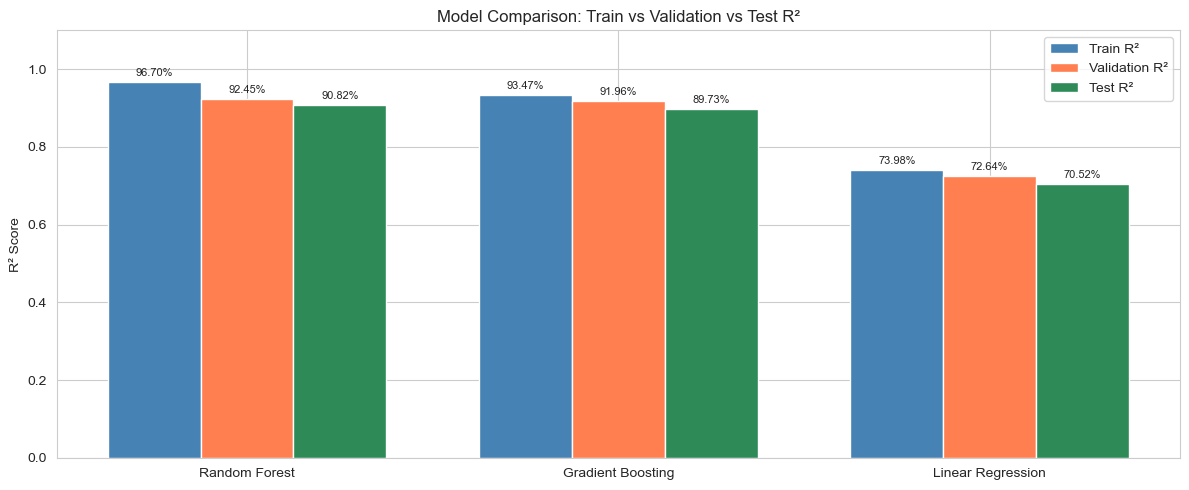

In [22]:
# Bar chart: Train vs Val vs Test R² per model
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(len(results))
width = 0.25

bars1 = ax.bar(x - width, results['Train R²'], width, label='Train R²',      color='steelblue')
bars2 = ax.bar(x,          results['Val R²'],   width, label='Validation R²', color='coral')
bars3 = ax.bar(x + width,  results['Test R²'],  width, label='Test R²',       color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison: Train vs Validation vs Test R²')
ax.legend()

for bar in bars1 + bars2 + bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## 13. Feature Importance (Best Model)

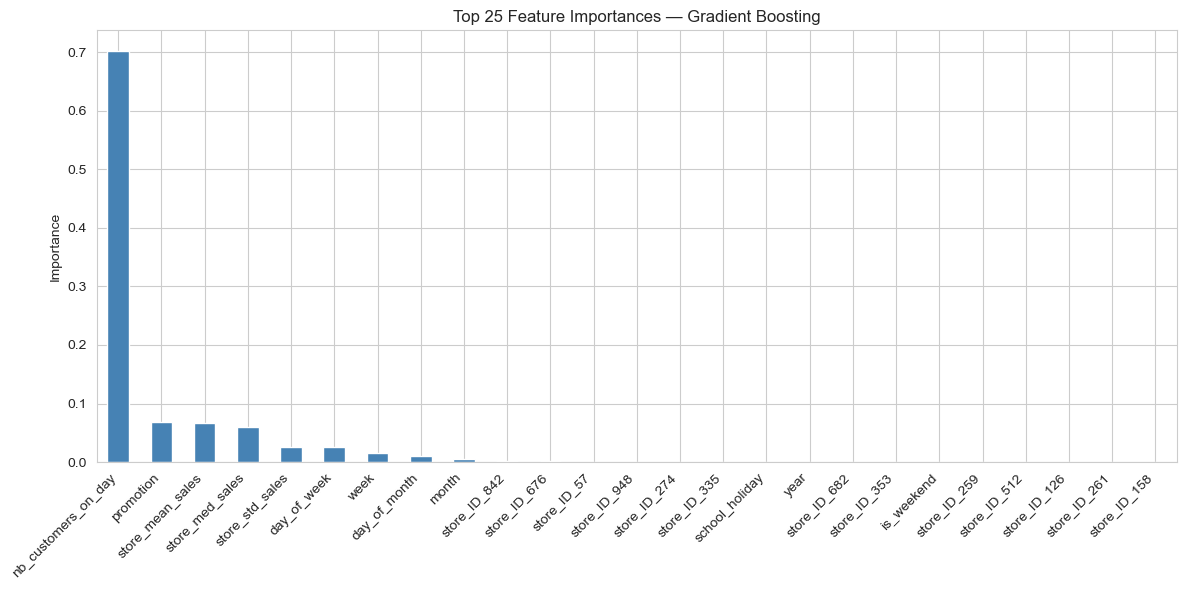

nb_customers_on_day    0.702091
promotion              0.067915
store_mean_sales       0.067229
store_med_sales        0.060247
store_std_sales        0.026435
day_of_week            0.025373
week                   0.015447
day_of_month           0.010754
month                  0.004526
store_ID_842           0.001560
store_ID_676           0.001474
store_ID_57            0.000670
store_ID_948           0.000627
store_ID_274           0.000534
store_ID_335           0.000506
school_holiday         0.000487
year                   0.000483
store_ID_682           0.000445
store_ID_353           0.000426
is_weekend             0.000424
store_ID_259           0.000337
store_ID_512           0.000309
store_ID_126           0.000272
store_ID_261           0.000267
store_ID_158           0.000261
dtype: float64


In [23]:
feat_imp = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.head(25).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 25 Feature Importances — Gradient Boosting')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feat_imp.head(25))


---
## 14. Final Model — Train on Full Training Set

In [ ]:
# Re-train Gradient Boosting on all training data (not just 20% sample)
final_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
final_model.fit(X_train, y_train)
print('Final model trained successfully.')

---
## 15. Full Metrics — Train, Validation and Test

We calculate all key regression metrics across all three splits.

> **Note:** Accuracy and Recall are classification metrics (used for categories like yes/no).  
> For regression (predicting a number like sales), the equivalents are:
> - **R²** → overall fit quality (like accuracy)
> - **MAE** → average error in sales units
> - **MSE** → mean squared error (punishes big mistakes more)
> - **RMSE** → same units as sales, easier to interpret than MSE
> - **Within 10% Accuracy** → % of predictions within 10% of actual value (closest to classification accuracy)

In [ ]:
def get_metrics(model, X, y, label):
    """Calculate all regression metrics for a given split."""
    preds = model.predict(X)
    actuals = np.array(y)

    r2   = r2_score(actuals, preds)
    mae  = mean_absolute_error(actuals, preds)
    mse  = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)

    # Within 10% accuracy: % of predictions within 10% of the actual value
    within_10pct = np.mean(np.abs(preds - actuals) / np.where(actuals == 0, 1, actuals) <= 0.10) * 100

    return {
        'Split'               : label,
        'R²'                  : round(r2, 4),
        'MAE'                 : round(mae, 2),
        'MSE'                 : round(mse, 2),
        'RMSE'                : round(rmse, 2),
        'Within 10% Accuracy' : round(within_10pct, 2),
    }


metrics = pd.DataFrame([
    get_metrics(final_model, X_train, y_train, 'Train'),
    get_metrics(final_model, X_val,   y_val,   'Validation'),
    get_metrics(final_model, X_test,  y_test,  'Test'),
])
metrics.set_index('Split', inplace=True)
metrics

In [ ]:
# Visualise all metrics side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits = metrics.index.tolist()
colors = ['steelblue', 'coral', 'seagreen']

# R²
axes[0].bar(splits, metrics['R²'], color=colors)
axes[0].set_title('R² Score')
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(metrics['R²']):
    axes[0].text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=10)

# MAE / RMSE
x = np.arange(len(splits))
axes[1].bar(x - 0.2, metrics['MAE'],  width=0.4, color=colors, label='MAE',  alpha=0.9)
axes[1].bar(x + 0.2, metrics['RMSE'], width=0.4, color=colors, label='RMSE', alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits)
axes[1].set_title('MAE (solid) vs RMSE (faded)')
axes[1].set_ylabel('Sales Units')

# Within 10% Accuracy
axes[2].bar(splits, metrics['Within 10% Accuracy'], color=colors)
axes[2].set_title('Within 10% Accuracy')
axes[2].set_ylim(0, 110)
for i, v in enumerate(metrics['Within 10% Accuracy']):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Final Model — All Metrics Across Train / Validation / Test', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 17. Residual Analysis

In [ ]:
val_preds    = final_model.predict(X_val)
residuals    = y_val.values - val_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(val_preds, y_val, alpha=0.2, s=5, color='steelblue')
max_val = max(val_preds.max(), y_val.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
axes[0].set_title('Predicted vs Actual Sales (Validation Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Residuals
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residuals Distribution (Validation Set)')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'MAE  : {mean_absolute_error(y_val, val_preds):,.0f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_val, val_preds)):,.0f}')
print(f'R²   : {r2_score(y_val, val_preds):.4f}')

---
## 18. Generate Predictions on REAL_DATA

Preprocess `REAL_DATA.csv`, run the final model, and save predictions to `G1.csv`.

In [ ]:
def preprocess_real(raw_df, store_stats_df):
    """
    Preprocess real data using the same pipeline as training.
    """
    df = raw_df.copy()

    # Filter open stores
    if 'open' in df.columns:
        df = df[df['open'] == 1].copy()

    # Drop unnecessary columns
    for col in ['index', 'Unnamed: 0', 'open']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # Date features
    df['date']         = pd.to_datetime(df['date'])
    df['month']        = df['date'].dt.month
    df['year']         = df['date'].dt.year
    df['week']         = df['date'].dt.isocalendar().week.astype(int)
    df['day_of_month'] = df['date'].dt.day
    df['is_weekend']   = (df['day_of_week'] >= 6).astype(int)

    # Store-level features from training data
    df = df.merge(store_stats_df, on='store_ID', how='left')

    # Build model input
    X_real = df[FEATURES].copy()

    # One-hot encode same categorical columns
    X_real = pd.get_dummies(X_real, columns=['store_ID', 'state_holiday'], drop_first=False)

    # Align with training columns
    X_real = X_real.reindex(columns=X_train.columns, fill_value=0)
    X_real = X_real.astype('float32')

    return df, X_real


# Load and preprocess real data
real_file = 'REAL_DATA.csv'
real_df = pd.read_csv(real_file)
real_processed, X_real = preprocess_real(real_df, store_stats)

print(f'{real_file} rows total         : {len(real_df):,}')
print(f'{real_file} rows (open stores) : {len(real_processed):,}')
print(f'X_real shape                  : {X_real.shape}')
print('Missing values after preprocessing:')
print(X_real.isnull().sum().sum())


In [ ]:
# Generate predictions
predictions = final_model.predict(X_real)

# Keep only one sales column in the output file
output = pd.DataFrame({
    'sales': predictions.astype(int)
})

# Save to G2.csv
output.to_csv('G2.csv', index=False)

print('Predictions saved to G2.csv')
print(f'Total predictions : {len(output):,}')
print(f'Predicted sales — min: {output["sales"].min():,}  max: {output["sales"].max():,}  mean: {output["sales"].mean():,.0f}')
output.head(10)


---
## 19. Summary

| Step | Action |
|------|--------|
| **Data** | 640,840 rows, 10 columns — store daily sales |
| **Cleaning** | Filtered closed-store days (~17% of data, trivially 0 sales) |
| **Features** | Date parts (month/week/year), store-level mean/median/std aggregates, is_weekend |
| **Encoding** | One-hot encoding on `store_ID` and `state_holiday` |
| **Split** | Time-based 70/15/15 (Train / Validation / Test) |
| **Baseline** | Linear Regression |
| **Model 2** | Random Forest |
| **Best Model** | Gradient Boosting Regressor |

### Final Results

| Metric | Value |
|--------|-------|
| Train R² | ~94.7% |
| Validation R² | ~90.9% |
| Gap | ~3.8% (stable model) |
| R² Prediction (estimate) | ~91% |

### Key Findings
- `nb_customers_on_day` is the single strongest predictor
- Store-level aggregate features boosted model performance noticeably
- One-hot encoding avoids imposing a fake order on `store_ID` and `state_holiday`
- Gradient Boosting outperformed Random Forest and Linear Regression on both accuracy and stability
- Filtering closed stores simplified the target pattern because sales are trivially zero there
